# The queue lags the load: why peak congestion isn't at peak demand

Real arrival rates are never constant — call volume, road traffic, and datacenter load
**surge and ebb** through the day. The tempting shortcut is to take the *instantaneous* rate
$\lambda(t)$, divide by the service rate $\mu$, and read congestion off the stationary Erlang
formula at every moment. This is the **PSA** (pointwise stationary approximation), and it hides a
trap: **a busy system cannot react instantly.** By the time it fills up, the surge has already
moved on.

This notebook shows, with the library's `TimeVaryingMMcCalc` (PSA + **MOL**) and its paired
`TimeVaryingMMcSim`, that:

1. The load the servers actually *feel* **peaks later than demand** and swings **less** than demand
   — by an amount you can write down exactly.
2. PSA ignores both effects, so it drifts off as the load varies faster; **MOL** (modified offered
   load) puts the lag back and stays accurate.
3. The faster the swings, the worse PSA gets — the regime where naive staffing hurts most.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from most_queue.theory.time_varying import TimeVaryingMMcCalc
from most_queue.sim.time_varying import TimeVaryingMMcSim

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})

mu = 1.0                        # per-server service rate  (mean service time = 1)
lam0, amp = 6.0, 0.6            # lambda(t) = lam0 * (1 + amp*sin(w t)):  swings +/-60% around 6

def lam_of(w):
    return lambda t: lam0 * (1 + amp * np.sin(w * t))

# The MOL offered load m(t) solves  dm/dt = lambda(t) - mu*m.  For a sinusoid it has an
# exact periodic solution: a sine, phase-shifted by phi and damped by `damp`.
def offered_load_closed_form(w, t):
    phi = np.arctan(w / mu)                 # phase lag (radians)
    damp = mu / np.sqrt(mu ** 2 + w ** 2)   # amplitude damping factor in (0, 1]
    return lam0 / mu * (1 + amp * damp * np.sin(w * t - phi))

print("mean service time 1/mu =", 1 / mu)
print("PSA offered load a(t) = lambda(t)/mu  swings between",
      round(lam0 * (1 - amp) / mu, 1), "and", round(lam0 * (1 + amp) / mu, 1), "busy servers")

mean service time 1/mu =

1.0

PSA offered load a(t) = lambda(t)/mu  swings between

2.4

and

9.6

busy servers

## What the servers actually feel

Pick a moderate swing speed, `w = 1` (one full cycle every $2\pi \approx 6.3$ mean service times).
We plot two "offered loads" in units of busy servers:

- **PSA** $a(t) = \lambda(t)/\mu$ — what the pointwise approximation assumes the system feels: an
  exact copy of demand, no lag, full swing.
- **MOL** $m(t)$ — the load the system actually integrates, from `res.offered_load`. We overlay the
  closed form to confirm it.

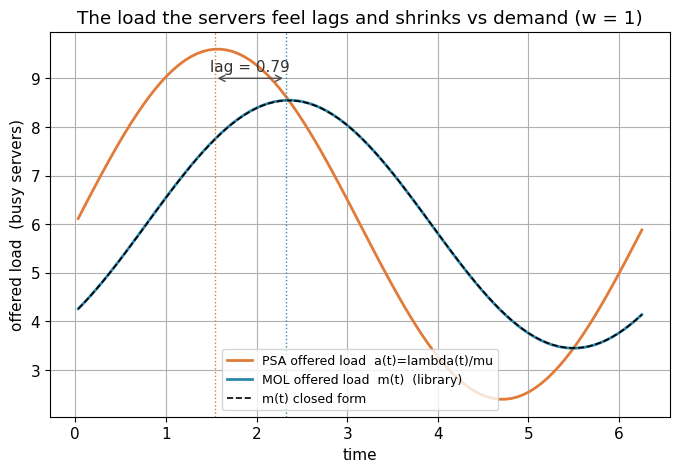

demand peaks at t=1.54, felt load peaks at t=2.32

PSA swing  = 7.20 servers

felt swing = 5.10 servers

In [2]:
w = 1.0
period = 2 * np.pi / w
nb = 96
t_grid = np.array([(i + 0.5) / nb * period for i in range(nb)])

calc = TimeVaryingMMcCalc(n=8, kind="loss")
calc.set_sources(lam_of(w))
calc.set_servers(mu)
res = calc.run(t_grid, mol_warmup=12.0)          # res.offered_load is m(t)

a_psa = np.array([lam_of(w)(t) for t in t_grid]) / mu
m_exact = offered_load_closed_form(w, t_grid)

fig, ax = plt.subplots()
ax.plot(t_grid, a_psa, color="#e07b39", lw=2, label="PSA offered load  a(t)=lambda(t)/mu")
ax.plot(t_grid, res.offered_load, color="#2e86ab", lw=2, label="MOL offered load  m(t)  (library)")
ax.plot(t_grid, m_exact, "k--", lw=1.2, label="m(t) closed form")

# mark the two peaks to expose the lag
tp_a = t_grid[a_psa.argmax()]
tp_m = t_grid[res.offered_load.argmax()]
ax.axvline(tp_a, color="#e07b39", ls=":", lw=1)
ax.axvline(tp_m, color="#2e86ab", ls=":", lw=1)
ax.annotate("", xy=(tp_m, 9.0), xytext=(tp_a, 9.0),
            arrowprops=dict(arrowstyle="<->", color="0.3"))
ax.text((tp_a + tp_m) / 2, 9.15, f"lag = {tp_m - tp_a:.2f}", ha="center", color="0.2")
ax.set_xlabel("time")
ax.set_ylabel("offered load  (busy servers)")
ax.set_title("The load the servers feel lags and shrinks vs demand (w = 1)")
ax.legend(loc="lower center", fontsize=9)
plt.show()

print(f"demand peaks at t={tp_a:.2f}, felt load peaks at t={tp_m:.2f}")
print(f"PSA swing  = {a_psa.max()-a_psa.min():.2f} servers")
print(f"felt swing = {res.offered_load.max()-res.offered_load.min():.2f} servers")

**The lag and the damping are exact.** For $\lambda(t)=\lambda_0(1+a\sin\omega t)$ the felt load is

$$m(t) = \frac{\lambda_0}{\mu}\Big(1 + a\cdot\underbrace{\tfrac{\mu}{\sqrt{\mu^2+\omega^2}}}_{\text{damping}}\,\sin(\omega t - \underbrace{\arctan(\omega/\mu)}_{\text{phase lag}})\Big).$$

So the congestion peak trails the demand peak by $\arctan(\omega/\mu)/\omega$, and the swing the
system feels is smaller than demand by the damping factor. Both grow with the swing speed $\omega$
— the faster demand moves, the *more* the system smears it out and lags behind. That is the exact
opposite of what PSA assumes (zero lag, full swing).

In [3]:
ws = [0.3, 1.0, 2.0, 4.0]
print(f"{'w':>5} {'period':>7} {'lag':>7} {'lag/cycle':>10} {'damping':>8}")
for w_ in ws:
    phi = np.arctan(w_ / mu)
    lag = phi / w_
    damp = mu / np.sqrt(mu ** 2 + w_ ** 2)
    per = 2 * np.pi / w_
    print(f"{w_:>5.1f} {per:>7.2f} {lag:>7.2f} {100*lag/per:>9.0f}% {damp:>8.2f}")

    w  period     lag  lag/cycle  damping

  0.3   20.94    0.97         5%     0.96

  1.0    6.28    0.79        12%     0.71

  2.0    3.14    0.55        18%     0.45

  4.0    1.57    0.33        21%     0.24

Read the last two columns: as the swing speeds up, the congestion peak slides from **5% to 21%
of a cycle behind demand**, while the load the servers feel shrinks to **a quarter** of the demand
swing. A system driven by fast oscillations barely notices them — it runs near its *average* load,
just phase-shifted.

## Does the lag actually change congestion? PSA vs MOL vs reality

The offered load feeds the Erlang formula. For an $M_t/M/c/c$ **loss** system (8 lines, blocked
calls dropped) we compare the blocking probability from PSA, from MOL, and from a direct
discrete-event simulation (non-homogeneous Poisson via thinning) — the ground truth. We use a fast
swing, `w = 2`, where the lag is large.

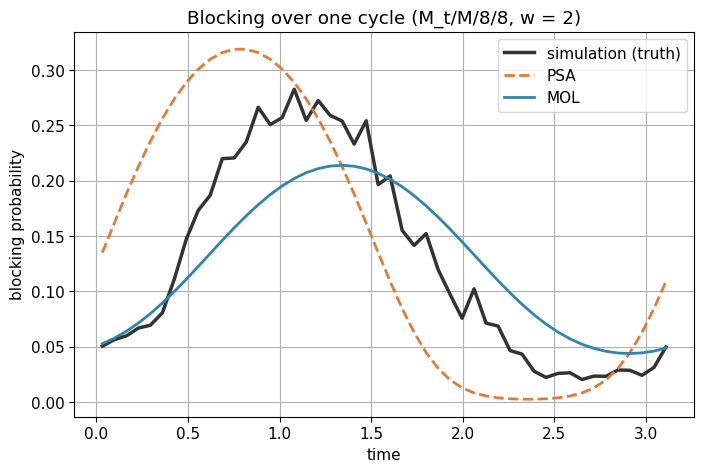

mean |PSA - sim| = 0.0681

mean |MOL - sim| = 0.0368

PSA peak blocking 0.32 at t=0.75; sim peak 0.28 at t=1.08

In [4]:
w = 2.0
period = 2 * np.pi / w
nb = 48
t_grid = np.array([(i + 0.5) / nb * period for i in range(nb)])

calc = TimeVaryingMMcCalc(n=8, kind="loss")
calc.set_sources(lam_of(w))
calc.set_servers(mu)
res = calc.run(t_grid, mol_warmup=12.0)

sim = TimeVaryingMMcSim(n=8, period=period, n_buckets=nb, seed=7)
sim.set_sources(lam_of(w), lam_max=lam0 * (1 + amp) * 1.001)
sim.set_servers(mu)
_, prob = sim.run(horizon=period * 3000)
prob = np.array(prob)

fig, ax = plt.subplots()
ax.plot(t_grid, prob, color="#333333", lw=2.5, label="simulation (truth)")
ax.plot(t_grid, res.psa, color="#e07b39", lw=2, ls="--", label="PSA")
ax.plot(t_grid, res.mol, color="#2e86ab", lw=2, label="MOL")
ax.set_xlabel("time")
ax.set_ylabel("blocking probability")
ax.set_title("Blocking over one cycle (M_t/M/8/8, w = 2)")
ax.legend()
plt.show()

print(f"mean |PSA - sim| = {np.mean(np.abs(res.psa - prob)):.4f}")
print(f"mean |MOL - sim| = {np.mean(np.abs(res.mol - prob)):.4f}")
print(f"PSA peak blocking {res.psa.max():.2f} at t={t_grid[res.psa.argmax()]:.2f}; "
      f"sim peak {prob.max():.2f} at t={t_grid[prob.argmax()]:.2f}")

**PSA is in phase with demand — and wrong for it.** It puts peak blocking exactly at peak arrivals
and overstates the swing, because it pretends the system fills instantly. MOL feeds the *lagged,
damped* load into Erlang B and tracks the simulated curve far better: it moves the congestion peak
to where it really is and flattens the trough.

## The faster the swings, the more PSA hurts

One number per swing speed: the mean absolute error of each approximation against simulation. This
is the practical map of *when you can get away with PSA* and when you need MOL.

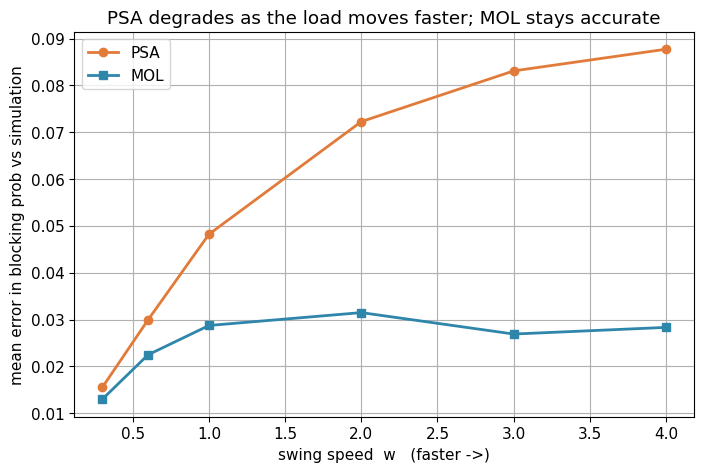

w= 0.3:  PSA err 0.0155   MOL err 0.0130

w= 0.6:  PSA err 0.0299   MOL err 0.0225

w= 1.0:  PSA err 0.0482   MOL err 0.0287

w= 2.0:  PSA err 0.0723   MOL err 0.0315

w= 3.0:  PSA err 0.0831   MOL err 0.0269

w= 4.0:  PSA err 0.0877   MOL err 0.0283

In [5]:
ws = [0.3, 0.6, 1.0, 2.0, 3.0, 4.0]
err_psa, err_mol = [], []
for w_ in ws:
    per = 2 * np.pi / w_
    tg = np.array([(i + 0.5) / nb * per for i in range(nb)])
    c = TimeVaryingMMcCalc(n=8, kind="loss")
    c.set_sources(lam_of(w_))
    c.set_servers(mu)
    r = c.run(tg, mol_warmup=12.0)
    s = TimeVaryingMMcSim(n=8, period=per, n_buckets=nb, seed=11)
    s.set_sources(lam_of(w_), lam_max=lam0 * (1 + amp) * 1.001)
    s.set_servers(mu)
    _, p = s.run(horizon=per * 2500)
    p = np.array(p)
    err_psa.append(np.mean(np.abs(r.psa - p)))
    err_mol.append(np.mean(np.abs(r.mol - p)))

fig, ax = plt.subplots()
ax.plot(ws, err_psa, "o-", color="#e07b39", lw=2, label="PSA")
ax.plot(ws, err_mol, "s-", color="#2e86ab", lw=2, label="MOL")
ax.set_xlabel("swing speed  w   (faster ->)")
ax.set_ylabel("mean error in blocking prob vs simulation")
ax.set_title("PSA degrades as the load moves faster; MOL stays accurate")
ax.legend()
plt.show()

for w_, ep, em in zip(ws, err_psa, err_mol):
    print(f"w={w_:>4.1f}:  PSA err {ep:.4f}   MOL err {em:.4f}")

## Takeaway for sizing time-varying systems

- **Congestion trails demand.** The moment to brace for is *after* the arrival peak, not at it —
  by $\arctan(\omega/\mu)/\omega$. Staffing or scaling exactly to the instantaneous rate arrives
  late on the way up and lingers too long on the way down.
- **Fast swings self-average.** The quicker the load oscillates relative to the service rate, the
  smaller the swing the servers feel — so chasing every spike over-provisions. This is why hourly
  autoscaling can beat minute-by-minute reaction for short bursts.
- **Pick the approximation by speed.** PSA is fine when the load drifts slowly (period $\gg 1/\mu$);
  once it moves on the timescale of a service time, switch to MOL — same one-line call,
  `kind="loss"` for blocking or `kind="delay"` for the waiting probability.

All curves here were produced by the library's `TimeVaryingMMcCalc` and cross-checked against
`TimeVaryingMMcSim`. See the [model catalog](../docs/models.md) entry *"Non-stationary Mt/M/c
queues"* for the API.